# Introduction to Data Science – Homework 5
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, February 20, 2026, 11:59pm.

In this homework you will use linear regression to study house prices in Salt Lake City.

## Your Data
Fill out the following information: 

*First Name:*   Yichun(Abby) 

*Last Name:*   Chen

*E-mail:* u1583033@umail.utah.edu

*UID:*  u1583033


# Importing all the libraries 

In [2]:
# imports and setup 
import pandas as pd
import scipy as sc
import numpy as np

import statsmodels.formula.api as sm

#%matplotlib notebook
import matplotlib.pyplot as plt 
plt.style.use('ggplot')
%matplotlib inline  
plt.rcParams['figure.figsize'] = (10, 6) 

## Regression of real estate data
For this problem, you will analyze SLC real estate data. The dataset contains multiple listing service (MLS) real estate transactions for houses sold in recent years in zip code 84103 ([SLC avenues neighborhood](https://www.google.com/maps/place/Salt+Lake+City,+UT+84103/@40.8030372,-111.8957957,12z/data=!3m1!4b1!4m5!3m4!1s0x87525f672006dded:0x311e638d9a1a2de5!8m2!3d40.810506!4d-111.8449346)). We are primarily interested in regressing the `SoldPrice` on the house attributes (`property size`, `house size`, `number of bedrooms`, etc...). 


### Task 1.1: Import the data 
Use the [`pandas.read_csv()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) function to import the dataset. The data is contained in two files located in the same directory as this notebook: [`train1.csv`](train1.csv) and [`train2.csv`](train2.csv). After you import these files separately, concatenate them into one big dataframe. This pandas dataframe will be used for data exploration and linear regression. 

In [3]:
# your code goes here
train1 = pd.read_csv("train1.csv")
train2 = pd.read_csv("train2.csv")

# joining two dataframes
train = pd.concat([train1,train2])
train.head()

,MLS_,Driveway,Acres,Air_Conditioning,Amenities,Area,Back_Dimensions,Basement,Basement_Finished,Canceled_Date,...,Total_Square_Feet,Construction_Status,Unit_Lot_Number,Water,Window,Withdrawn_Date,Year_Built,Zip,Zoning_Character,Last_Modified_Date
0,1987748,Concrete,0.01,Central Air; Electric,Clubhouse; Electric Dryer Hookup; Exercise Roo...,Salt Lake City: Avenues Area,0.0,None/Crawl Space,0,00/00/0000,...,"1,648",NaN,802,Culinary,Blinds; Full,00/00/0000,1976,84103,5905,5/10/2024
1,1993546,Common Drive,0.09,Central Air; Electric,Cable TV Available; Electric Dryer Hookup,Salt Lake City: Avenues Area,0.0,Other,0,00/00/0000,...,"2,633",NaN,NaN,Culinary,Blinds; Full,00/00/0000,1895,84103,1205,5/24/2024
2,1991915,Asphalt,0.01,Central Air; Electric,Exercise Room; Gated Community; Swimming Pool,Salt Lake City: Avenues Area,0.0,None/Crawl Space,0,00/00/0000,...,826,NaN,138,Culinary,NaN,00/00/0000,1961,84103,RMF-35,6/20/2024
3,1881930,Concrete,0.11,Central Air; Electric,Cable TV Wired; Electric Dryer Hookup; Gas Dry...,Salt Lake City: Avenues Area,0.0,Daylight; Full,100,00/00/0000,...,"2,653",NaN,NaN,Culinary,Blinds; Full; Shades,00/00/0000,1956,84103,1205,5/15/2024
4,2023690,Concrete,0.01,Central Air; Electric; Active Solar,Home Warranty,Salt Lake City: Avenues Area,0.0,None/Crawl Space,0,00/00/0000,...,935,NaN,25-May,NaN,NaN,00/00/0000,2024,84103,NaN,12/27/2024


# Task 1.2: Understand the Data

Now that the data is loaded. Try to understand the data. Domain knowledge is always important for most data science tasks.

- Print different information and statistics of the data (i.e. df.head(), df.info(), df.describe(), df.shape, df.columns etc.). There are 172 different variables associated with each of the 555 houses in this dataset. Skim them and try to get a rough understanding of what information this dataset contains. If you've never seen a real estate listing before, you might take a look at one on [utahrealstate.com](http://www.utahrealestate.com/) website to get a better sense of the meanings of the column headers in the dataset.  

- Print all the columns of the data

In [4]:
# Code goes here
train.describe()

,MLS_,Acres,Back_Dimensions,Basement_Finished,Contact_Phone_One,Contact_Phone_Two,Contact,Carport_Capacity,DOM,Decks,...,Total_Three_quarter_Bathrooms,Total_Family_Rooms,Total_Fireplaces,Total_Formal_Dining_Rooms,Total_Kitchens,Total_Laundry_Rooms,Total_Semi_formal_Dining_Rooms,Construction_Status,Year_Built,Zip
count,5.550000e+02,555.000000,555.000000,555.000000,0.0,0.0,0.0,555.000000,514.000000,555.000000,...,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,8.0,555.000000,555.0
mean,1.937132e+06,0.142667,1.007387,38.909910,NaN,NaN,NaN,0.126126,56.900778,0.639640,...,0.715315,1.028829,0.958559,0.338739,0.918919,0.969369,0.506306,1.0,1956.093694,84103.0
std,6.482822e+04,0.293939,8.363707,45.907014,NaN,NaN,NaN,0.427340,62.358799,0.794757,...,0.816150,0.720433,1.014379,0.477503,0.519218,0.450590,0.545292,0.0,39.837874,0.0
min,1.811200e+06,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1852.000000,84103.0
25%,1.875286e+06,0.010000,0.000000,0.000000,NaN,NaN,NaN,0.000000,10.250000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.0,1915.500000,84103.0
50%,1.955201e+06,0.080000,0.000000,0.000000,NaN,NaN,NaN,0.000000,37.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.0,1963.000000,84103.0
75%,1.994768e+06,0.160000,0.000000,95.000000,NaN,NaN,NaN,0.000000,81.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1980.000000,84103.0
max,2.058026e+06,4.590000,115.000000,100.000000,NaN,NaN,NaN,4.000000,385.000000,5.000000,...,5.000000,4.000000,6.000000,2.000000,3.000000,3.000000,2.000000,1.0,2024.000000,84103.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555 entries, 0 to 277
Columns: 172 entries, MLS_ to Last_Modified_Date
dtypes: float64(29), int64(51), object(92)
memory usage: 750.1+ KB


In [11]:
cols = train.columns
print(cols)

Index(['MLS_', 'Driveway', 'Acres', 'Air_Conditioning', 'Amenities', 'Area',
       'Back_Dimensions', 'Basement', 'Basement_Finished', 'Canceled_Date',
       ...
       'Total_Square_Feet', 'Construction_Status', 'Unit_Lot_Number', 'Water',
       'Window', 'Withdrawn_Date', 'Year_Built', 'Zip', 'Zoning_Character',
       'Last_Modified_Date'],
      dtype='object', length=172)


### Task 2: Clean the data 

- Only keep houses with Listing Price between 300,000 and 900,000 dollars both inclusive; use **and** condition to filter out the rest. This is an arbitrary choice and we realize that some people are high rollers, but for our purposes we'll consider the others as outliers. 

- Remove columns that you don't think contribute to the value of the house. This is a personal decision – what attributes of a house are important to you? 
You should at least keep the following variables since questions below will use them: `['Acres', 'Back_Dimensions', 'Total_Kitchens', 'East_West_Coordinates', 'North_South_Coordinates', 'DOM', 'Sold_Price', 'Parking_Capacity', 'Property_Type', 'Listing_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']` 

- Check the datatypes and convert any numbers that were read as strings to numerical values. (Hint: You can use [`str.replace()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.str.replace.html) to work with strings.) If there are any categorical values you're interested in, then you should convert them to numerical values as in Lecture. In particular, convert 'Total Square Feet' to an integer and add a column titled `Property_Type_Num` that is 
$$
\text{Property\_Type\_Num}_i = \begin{cases} 
2 & \text{if $i$-th listing is a Townhouse} \\
1 & \text{if $i$-th listing is a Condo} \\
0 & \text{if $i$-th listing is a Single Family}
\end{cases}. 
$$

- Drop all rows with `Estimated_Taxes` = 1.

In [12]:
# your code goes here
#filter house listing price
price_within_range = train[(train["Listing_Price"] >= 300000) & (train["Listing_Price"] <= 900000)]
price_within_range.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 277
Columns: 172 entries, MLS_ to Last_Modified_Date
dtypes: float64(29), int64(51), object(92)
memory usage: 471.7+ KB


In [13]:
# remove columns
remove_cols = price_within_range[['Acres', 'Back_Dimensions', 'Total_Kitchens', 'East_West_Coordinates', 'North_South_Coordinates', 'DOM', 'Sold_Price', 'Parking_Capacity', 'Property_Type', 'Listing_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']]
remove_cols["Total_Square_Feet"]= remove_cols["Total_Square_Feet"].str.replace(",","")
remove_cols["Total_Square_Feet"] = remove_cols["Total_Square_Feet"].astype("float64")

remove_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 277
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Acres                    349 non-null    float64
 1   Back_Dimensions          349 non-null    float64
 2   Total_Kitchens           349 non-null    int64  
 3   East_West_Coordinates    349 non-null    int64  
 4   North_South_Coordinates  349 non-null    int64  
 5   DOM                      320 non-null    float64
 6   Sold_Price               349 non-null    int64  
 7   Parking_Capacity         349 non-null    int64  
 8   Property_Type            349 non-null    object 
 9   Listing_Price            349 non-null    float64
 10  Estimated_Taxes          341 non-null    float64
 11  Total_Bedrooms           349 non-null    int64  
 12  Total_Bathrooms          349 non-null    int64  
 13  Total_Square_Feet        349 non-null    float64
 14  Year_Built               349 no

C:\Users\abbyc\AppData\Local\Temp\ipykernel_5464\3033733364.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remove_cols["Total_Square_Feet"]= remove_cols["Total_Square_Feet"].str.replace(",","")
C:\Users\abbyc\AppData\Local\Temp\ipykernel_5464\3033733364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remove_cols["Total_Square_Feet"] = remove_cols["Total_Square_Feet"].astype("float64")


In [54]:
# replace values
remove_cols["Property_Type_Num"] = remove_cols["Property_Type"].replace({"Townhouse":2,"Condo":1,"Single Family":0})
remove_cols["Property_Type_Num"] = remove_cols["Property_Type_Num"].astype("Int64")
remove_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 277
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Acres                    349 non-null    float64
 1   Back_Dimensions          349 non-null    float64
 2   Total_Kitchens           349 non-null    int64  
 3   East_West_Coordinates    349 non-null    int64  
 4   North_South_Coordinates  349 non-null    int64  
 5   DOM                      320 non-null    float64
 6   Sold_Price               349 non-null    int64  
 7   Parking_Capacity         349 non-null    int64  
 8   Property_Type            349 non-null    int64  
 9   Listing_Price            349 non-null    float64
 10  Estimated_Taxes          341 non-null    float64
 11  Total_Bedrooms           349 non-null    int64  
 12  Total_Bathrooms          349 non-null    int64  
 13  Total_Square_Feet        349 non-null    float64
 14  Year_Built               349 no

C:\Users\abbyc\AppData\Local\Temp\ipykernel_5464\458122364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remove_cols["Property_Type_Num"] = remove_cols["Property_Type"].replace({"Townhouse":2,"Condo":1,"Single Family":0})
C:\Users\abbyc\AppData\Local\Temp\ipykernel_5464\458122364.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remove_cols["Property_Type_Num"] = remove_cols["Property_Type_Num"].astype("Int64")


In [70]:
cleaned_df = remove_cols
cleaned_df = cleaned_df[cleaned_df["Estimated_Taxes"] != 1]
cleaned_df=cleaned_df.drop("Property_Type", axis = 1)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 337 entries, 0 to 277
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Acres                    337 non-null    float64
 1   Back_Dimensions          337 non-null    float64
 2   Total_Kitchens           337 non-null    int64  
 3   East_West_Coordinates    337 non-null    int64  
 4   North_South_Coordinates  337 non-null    int64  
 5   DOM                      313 non-null    float64
 6   Sold_Price               337 non-null    int64  
 7   Parking_Capacity         337 non-null    int64  
 8   Listing_Price            337 non-null    float64
 9   Estimated_Taxes          329 non-null    float64
 10  Total_Bedrooms           337 non-null    int64  
 11  Total_Bathrooms          337 non-null    int64  
 12  Total_Square_Feet        337 non-null    float64
 13  Year_Built               337 non-null    int64  
 14  Property_Type_Num        337 no

### Task 3: Exploratory data analysis and Visulization

- Make a bar chart showing the breakdown of the different types of houses (single family, townhouse, condo). 

- Compute the correlation matrix and use a heat map to visualize the correlation coefficients. 
    - Use a diverging color scale from -1 to +1 (see `vmin` and `vmax` parameters for [pcolor](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.pcolor.html))
    - Show a legend
    - Make sure the proper labels are visible and readable (see [`xticks`](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.xticks.html) and the corresponding [`yticks`](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.yticks.html)).
    - Keep in mind correlation can be calculated among features with numercial values.

- Make a scatter plot matrix to visualize the correlations.

    - Color-code the dots by property type. For the plot, only use a subset of the columns: `['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']`.
    - Determine which columns have strong correlations.
    - Set diagonal='kde' and explain what the diagonal plots are.

- Describing your findings.
#### Optional Task
Another great way to visualize the correlations is using scatter plot matrix. If you color-code the dots by property type and draw the distribution of the variable in the diagonal cells of the matrix, you will see a beautiful graph of correlations (Hint: Use `pd.plotting.scatter_matrix`). You should use only a subset of the columns: `['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']`. 

**Hint**: Use the code beloww to create a color map.

```python
type_color_map = red["Property_Type"].map({"Single Family":"#ca0020", "Condo":"#0571b0", "Townhouse":"#1b7837"})
```

And then use that as color in the plotting function like below

```python
pd.plotting.scatter_matrix(df, figsize=figsize, diagonal='kde', color=type_color_map)` function.
```


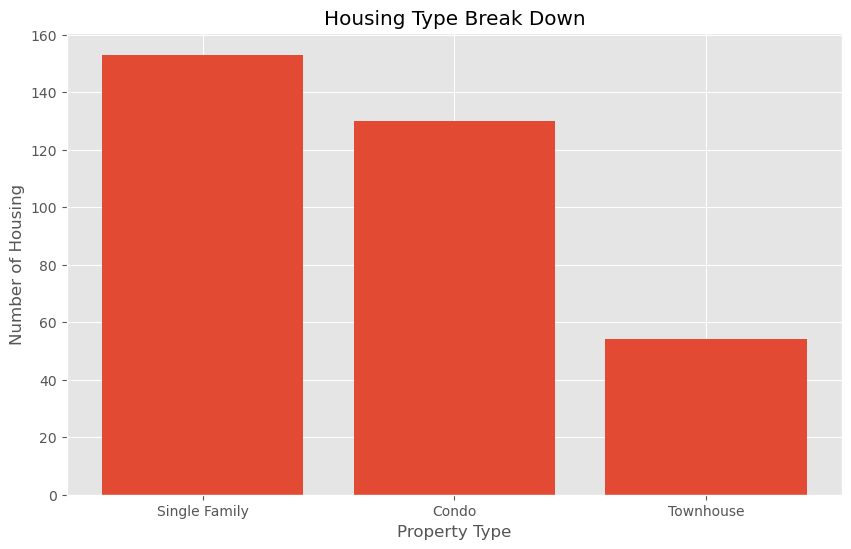

In [71]:
# your code goes here (You can use as many cells as you want, and as many markdown cells for explanations as you want)

# bar chart for the housing break down
housing_ops = cleaned_df.groupby("Property_Type_Num").size().reset_index()
housing_ops["Property_Type_Num"] = housing_ops["Property_Type_Num"].astype(object).replace({2:"Townhouse",1:"Condo",0:"Single Family"})
housing_ops.columns = ["Property Type", "Count"]
x = housing_ops["Property Type"]
y = housing_ops["Count"]

plt.bar(x,y)
plt.xlabel("Property Type")
plt.ylabel("Number of Housing")
plt.title("Housing Type Break Down")
plt.show()

From the graph, we can clearly see that singe family housing is by far the most popular following by condo. There's a significant decrease for town house. It's worthy to take a look into why townhouse is much less popular compare to other two housing type. 

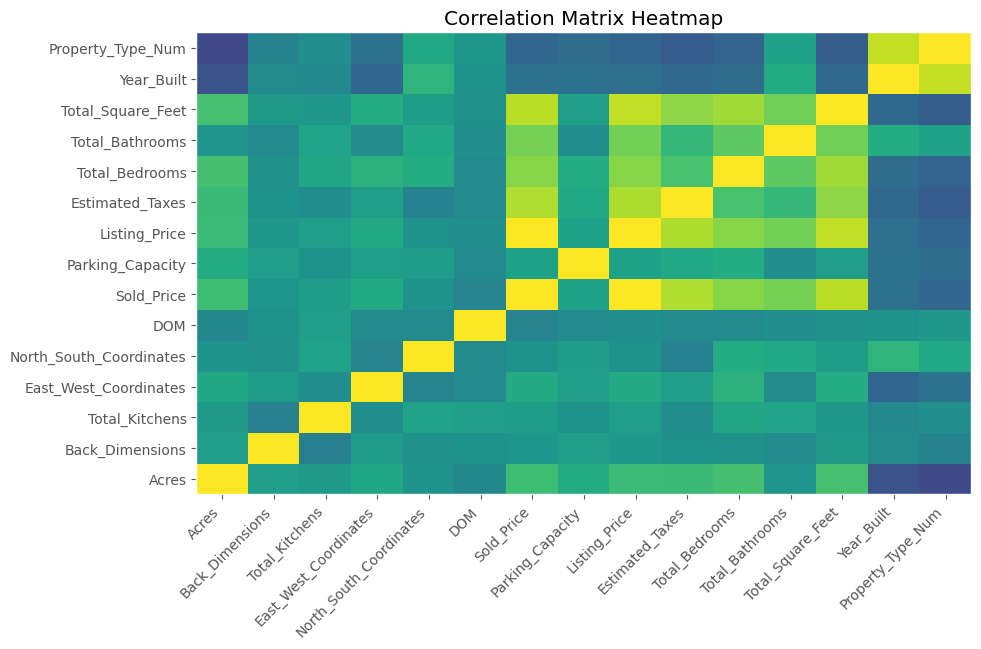

In [72]:
# correlation matrix and heat map
corr = cleaned_df.corr()

plt.pcolor(corr,vmin=-1,vmax=1)
plt.xticks(np.arange(0.5, len(corr.columns), 1),
           corr.columns,
           rotation=45, ha='right')

plt.yticks(np.arange(0.5, len(corr.columns), 1),
           corr.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

The heatmap shows the correlation between each features. The lighter the color, more correlate these features are. We can see that listing price is highly related to sold price which will make sense logically. Property type is not really related to acres at all. Other factors that will impace sold price include estimated taxes, total number of bathroom and bedrooms and also the total square feet. It also looks like that DOM is not really influenced or related to any other features.

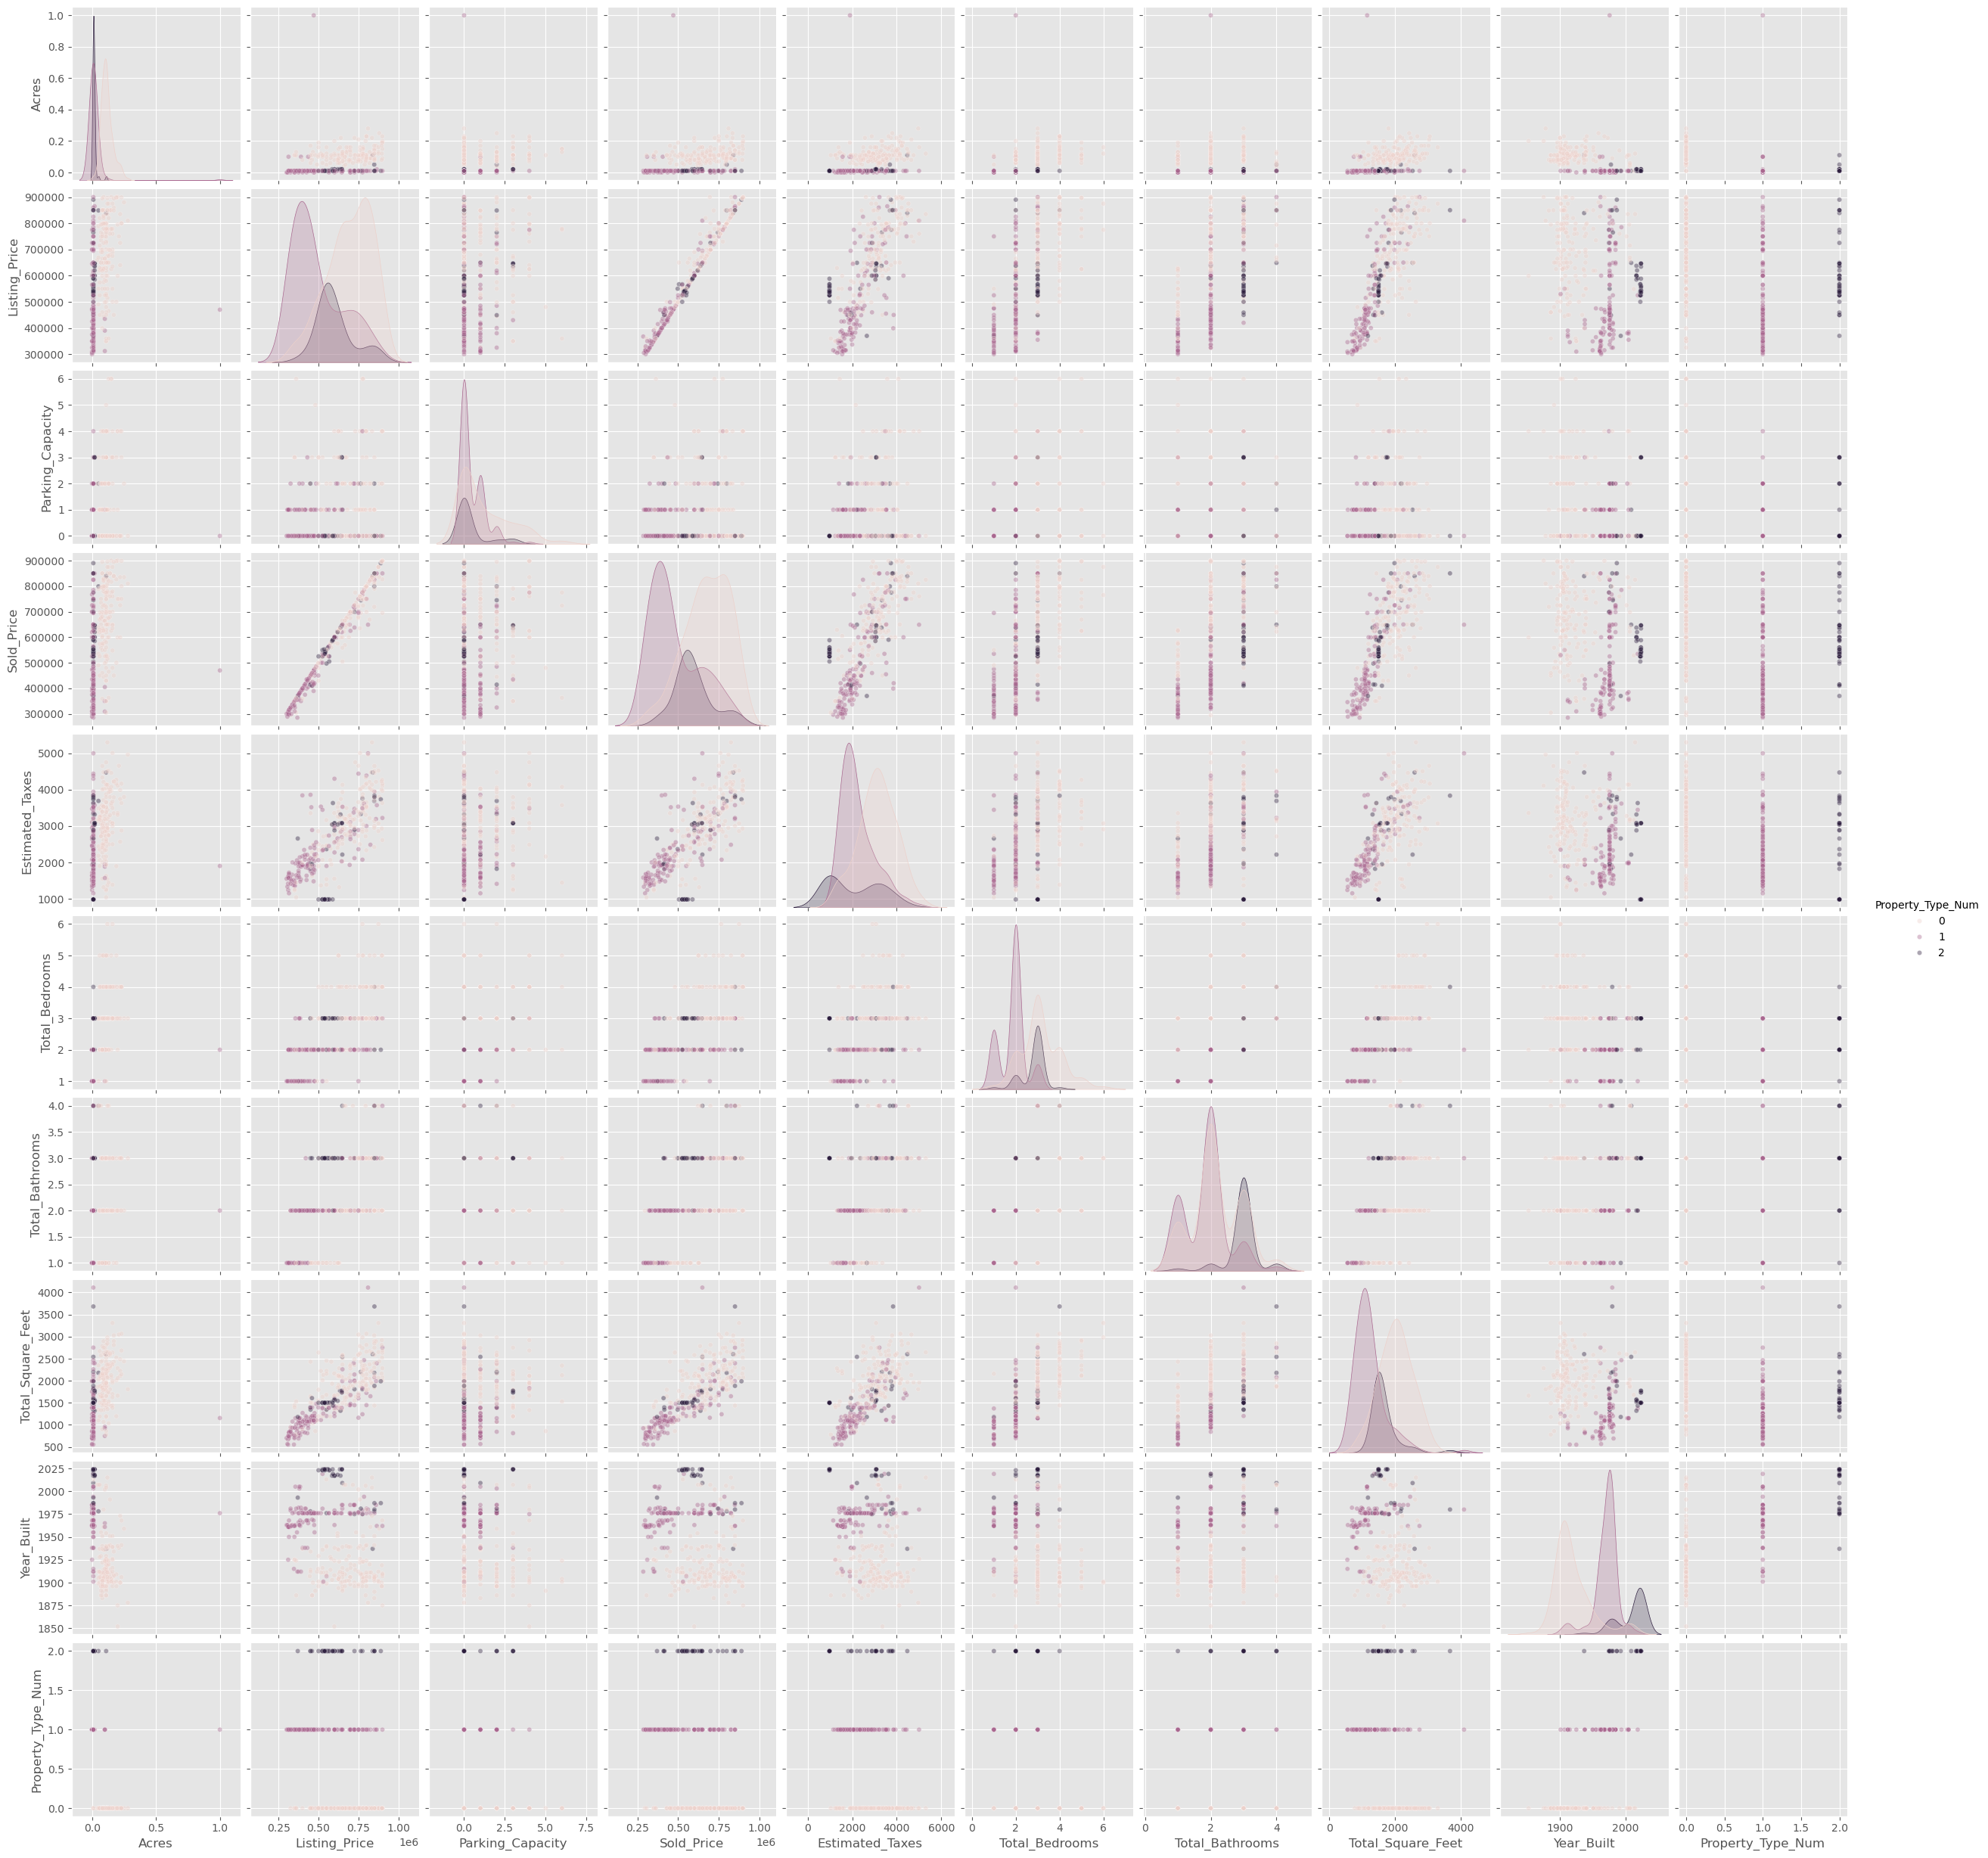

In [ ]:
# scatter plot
cols = ['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built','Property_Type_Num']
subset = cleaned_df[cols].dropna()


import seaborn as sns

sns.pairplot(subset,
             vars=cols,
             hue='Property_Type_Num',
             diag_kind='kde',
             plot_kws={'alpha':0.4, 's':20})

plt.show()



**Interpretation Question**
- Interpret the correlation matrix; what are the most and least correlated features? Which features do you expect to have most significance in price? 
- What does the scatter matrix show? Which features are most and least correlated to one another.
- How do you compare the scatter matrix to the correlation matrix?
- Explain why the features of your choice might have the most significance?

**Your Interpretation:** TODO

The most correlated features are listing price and sold price. The least correlated features property type and acres or housing price. We can't see a clear pattern of a upward or downward trend. I think the feature that influence the (listing and selling) price the most is the total square feet. 

The scatter matrix confirms the correlation showed with the heat map. There's a clear upward trend between estimated taxes, total square feet and the listing and solf price. Acres, property type and year build seen to be not really correlated with other features.

The correlation matrix shows us the numeric values of how each feature is related to each other. The scatter matrix provides a visual confirmation of what we saw in the correlation matrix. It also shows outliers and also the different clusters formed. 

The most significance feature can be the total quare feet since it's correlated with quite a few features. Buyers will consider whether they will buy the home or not based on how big they want the home to be. It also directly impact the price (bigger the house, higher the price), the number of bathroom and bedroom. Taxes is also another important feature. Taxes are calculated based on the value of the house. Thus, higher taxes can indicate to customers that this is a better house.


### Task 4: Geospatial plot
Two of the variables are the East-West Coordinates and North-South Coordinates of each listing. These values are extracted from the latitude and longitude of each listing in Salt Lake City. Create a scatterplot of these two variables. Use color to indicate the listing price of the house. 

What can you say about the relation between the location and the listing price?  

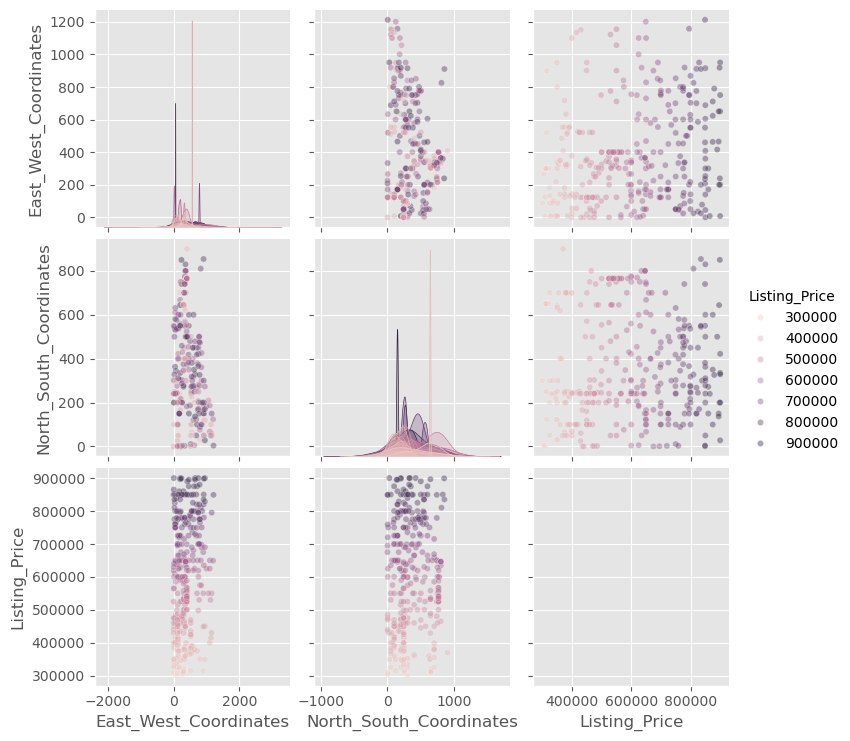

In [90]:
# your code goes here
coordination = cleaned_df[["East_West_Coordinates","North_South_Coordinates","Listing_Price"]]

sns.pairplot(coordination,
             vars=["East_West_Coordinates","North_South_Coordinates","Listing_Price"],
             hue='Listing_Price',
             diag_kind='kde',
             plot_kws={'alpha':0.4, 's':20})

plt.show()

**Your Interpretation:** TODO

There's not really a correlation between listing price and the coordinations of the housing. It doesn't necessarily suggest that the housing will get more expensive if it's up north. Expensive houses and cheap houses are scattered even across each coordinates. However, we are able to observe that the housing in this data set falls within a certain region of coordination.The KDE graphs show that different listing price are on top of each other, this further confirms that the location is not a strong indicator for listing price. 

### Task 5: Simple  Linear Regression 
Use the `ols` function from the [statsmodels](http://www.statsmodels.org/stable/index.html) package to do several simple linear regressions. Each model should be of the form Sold_Price = beta_0 + beta_1 * x, where x is one of the predictor variables that you choose and the target is predicting Sold_Price. Do this for at least three different predictor variables (other than Sold_Price).

$$
\text{Sold Price} = \beta_0 + \beta_1 x, 
$$

The best predictor can be identified as the variable that results in the highest R^2 value in the regression model. 
- You'll find the best predictor of the Sold_Price. Is it what you expected from Task 3? 
- Report the R-squared value for this model (`Sold_Price ~ BestPredictor`) and give an interpretation for its meaning.
- Also give an interpretation of $\beta_1$ for the model of Sold_Price best predictor.
- Make a scatterplot of Sold_Price ~ Listing_Price and overlay the prediction coming from your regression model.

**Hint.** You can try the variables with highest correlations with Sold_Price to find the best predictor.

In [99]:
# Your code here
# listing price
model_lp = sm.ols('Sold_Price ~ Listing_Price', data=cleaned_df).fit() # smf.ols("Dependent_Variable ~ Independent_Variable", data=df)
print(model_lp.rsquared)
# estimated tax
model_et= sm.ols('Sold_Price ~ Estimated_Taxes', data=cleaned_df).fit() 
print(model_et.rsquared)
# total square feet
model_tsf= sm.ols('Sold_Price ~ Total_Square_Feet', data=cleaned_df).fit() 
print(model_tsf.rsquared)

0.9713981138447156
0.5777621371161439
0.630562264707416


In [103]:
# listing price model output
model_lp.params

Intercept        3252.311459
Listing_Price       0.971440
dtype: float64

**Your Interpretation:** TODO

1. The best predictor I found is the Listing Price which is what I expected in the previous excercise. 
2. The listing price model has a R square value of 0.9714. This means that 97% of the variance in the sold price can be explained by the listing price.
3. The beta_1 value which is the slope for the linear function for Listing Price is also 0.9714. This means that for every 1$ increase in listing price, the sold price will increase about 0.97$ on average. 

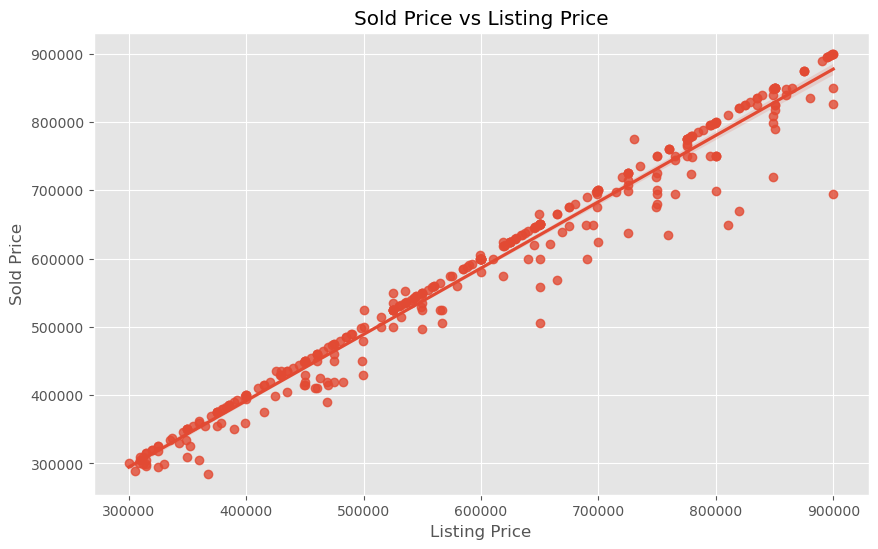

In [104]:
# scatter plot
sns.regplot(x="Listing_Price", y="Sold_Price", data=cleaned_df)

plt.title("Sold Price vs Listing Price")
plt.xlabel("Listing Price")
plt.ylabel("Sold Price")
plt.show()

We can see the data points for listing price and sold price lay almost perfectly on the diagnol line indicating the strong linear positive relationship between these two features. 

### Task 6: Multilinear Regression 
Develop a multilinear regression model for house prices in this neighborhood. We could use this to come up with a list price for houses coming on the market, so do not include the list price in your model and, for now, ignore the categorical variable Property_Type or it's one-hot encodings. Your model should be of the form:
$$
\text{Sold Price} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots +  \beta_n x_n, 
$$
where $x_i$ are predictive variables.


**Question 1**: If we wanted to start a 'house flipping' company, we'd have to be able to do a better job of predicting the sold price than the list price does. How does your new model compare to the model in Task 5 just using list price?

Next look at the difference between list price and sold price explicitly. Calculate two new columns for your dataset. `DiffPriceAbsolute` and `DiffPriceRelative`.

* `DiffPriceAbsolute` - This is difference between sold price and list price. If it is positive, that means the house sold for more than it was listed at.
* `DiffPriceRelative` - This is the relative difference between sold price and list price. A value of 1.1 here means that the house sold for 110% of the listing price, and 0.9 means the house sold for 90% of the listing price.

Now, create two new models. One to predict `DiffPriceAbsolute`, and one to predict `DiffPriceRelative`. Use the same predictive variables as in the last model.


**Question 2**: Which of these two new models makes better predictions?

**Question 3**: Based on your answer to question two, why are these models different/the same?

To help justify your answer to question 3, train two models to predict `DiffPriceAbsolute` and `DiffPriceRelative` based on just `Sold_Price`. In addition, for each model make a scatterplots similar to Task 5 for these models.

In [113]:
# MLP model
mlp = sm.ols("sold_price ~ Estimated_Taxes + Total_Square_Feet + Total_Bedrooms + Total_Bathrooms", data=cleaned_df).fit()
mlp.rsquared

np.float64(0.7725353608258179)

The R square value for the multilinear regression model is 0.773 which is smaller compared to the linear regression built with only listing price. This suggest that the listing price alone is a stronger predicter compared to all the other features combined. However, this multilinear model is outperforming any of the linear regression model build using only one features from the list. So if we want to using these features to predict the sold price, we should consider using a multilinear regression model. 

In [106]:
# Question 1
cleaned_df["DiffPriceAbsolute"] = (cleaned_df["Sold_Price"] - cleaned_df["Listing_Price"])
cleaned_df["DiffPriceRelative"] = (cleaned_df["Sold_Price"] / cleaned_df["Listing_Price"])
model_abs = sm.ols("DiffPriceAbsolute ~ Estimated_Taxes + Total_Square_Feet + Total_Bedrooms + Total_Bathrooms", data=cleaned_df).fit()
model_rel = sm.ols("DiffPriceRelative ~ Estimated_Taxes + Total_Square_Feet + Total_Bedrooms + Total_Bathrooms", data=cleaned_df).fit()

In [ ]:
# Question 2
print(model_abs.rsquared)
print(model_rel.rsquared)
# The absolute model is slightly a better model.

0.05804061517662995
0.034752022437748664


Question 3:
The absolute model is heavily influenced by the price difference.Larger and more expensive homes tend to experience larger dollar differences between listing and sold price. In contrast, the relative difference model standardizes the price difference by dividing by listing price, which removes the scale effect. Since percentage over or under asking does not vary as strongly with house size, it is more difficult to predict using structural characteristics alone.

In [ ]:
# models based on sold price
model_abs_sp = sm.ols("DiffPriceAbsolute ~ Sold_Price",data=cleaned_df).fit()
model_rel_sp = sm.ols("DiffPriceRelative ~ Sold_Price",data=cleaned_df).fit()


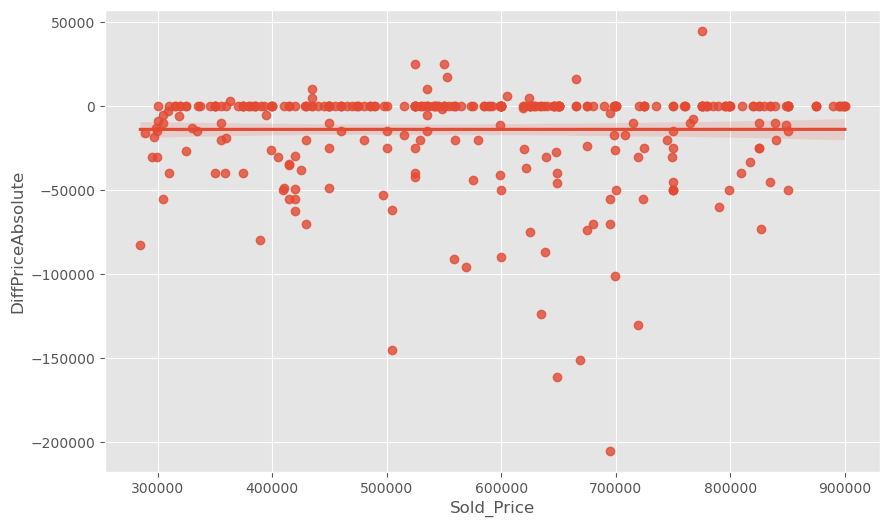

In [115]:
# abs scatter plot
sns.regplot(x="Sold_Price", y="DiffPriceAbsolute", data=cleaned_df)
plt.show()

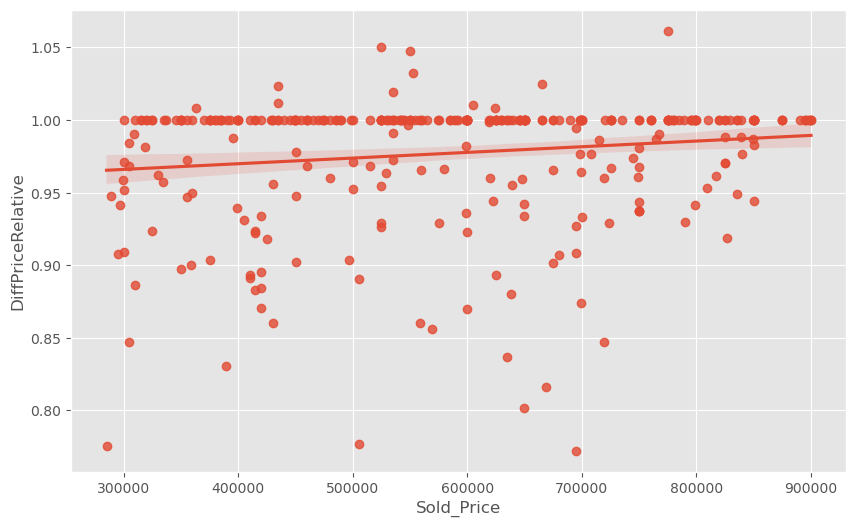

In [116]:
# rel
sns.regplot(x="Sold_Price", y="DiffPriceRelative", data=cleaned_df)
plt.show()

The scatter plot suggested opposite result compared to R2 values. This could due to the abs values contains lots of large values and massive outliers. Even explaining a small structured trend could reduce the variance which can lead to misleading higher R2 value. The relative model has more stable variance and tighter clusters. The visualization is more interpretable because it accounts for the pricing scale even though it has a lower R2 values.

### Task 7: Incorporating a categorical variable

Above, we considered houses, townhouses, and condos together, but here we'll distinguish between them. Consider the three regression models: 
$$
\text{Sold\_Price} = \beta_0 + \beta_1 \text{Property\_Type\_num}
$$
, 
$$
\text{Sold\_Price} = \beta_0  + \beta_1 \text{Property\_Type\_num} + \beta_2 \text{Total\_Square\_Feet}
$$
and 
$$
\text{Sold\_Price} = \beta_0  + \beta_1 \text{Feature1} + \beta_2 \text{Feature2}
$$
From the first model, it would appear that Property type is significant in predicting the sold price. On the other hand, the second model indicates that when you take into account total square footage, property type is no longer predictive. 
- Explain this.
- Make a scatterplot of Total_Square_Feet vs. Sold_Price where the house types are colored differently to illustrate your explanation. 

Now, we want to improve the prediction of sold price, without directly usig a price-based feature. From data analysis (task 3) find the best two predictive features; except for Listing_Price, and fit a model to predict the Sold_Price, as your Model 3. 
- Explain how these features changed the performance.
- Make scatterplots of Feature1 vs. Sold_Price and Feature2 vs. Sold_Price. How do you interpret the new plot?



**Your Interpretation:** TODO

In [119]:
# model 1 and 2
model_1 = sm.ols("Sold_Price ~ Property_Type_Num", data=cleaned_df).fit()
print(model_1.rsquared)
model_2 = sm.ols("Sold_Price ~ Property_Type_Num + Total_Square_Feet", data=cleaned_df).fit()
print(model_2.rsquared)



0.1183500389833837
0.6308892226576996


1. For both models, both the property type and the total square feet is directly connected to the sold price. Different property type will correspond to different sizes which that will determine the sold price. In the first model, property type is proxying the size. It might seems like property type is predicting the size but in fact it could be property type predicting the size and then predicting the price. In model 2, we have total square feet involve in the model. When we know the size of the house, then it doesn't matter what property type it is. A condo can be worth the same if it's the same size as a house. Thus, property type is no longer predictive in this case.

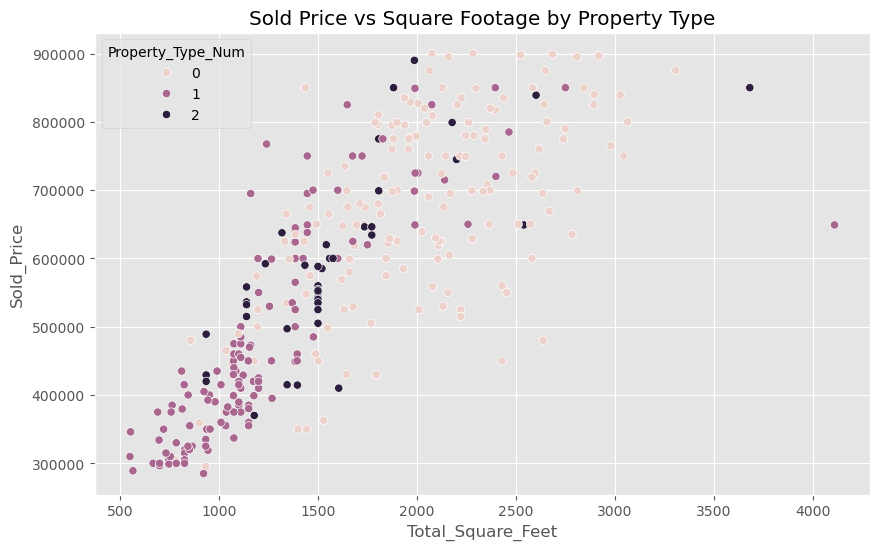

In [117]:
# Total Square Feet vs. Sold Price.
sns.scatterplot(
    data=cleaned_df,
    x="Total_Square_Feet",
    y="Sold_Price",
    hue="Property_Type_Num"
)

plt.title("Sold Price vs Square Footage by Property Type")
plt.show()

In [122]:
# model 3
model_3 = sm.ols("Sold_Price ~ Estimated_Taxes + Total_Bedrooms", data=cleaned_df).fit()
model_3.rsquared


np.float64(0.701751544539886)

Two most predicitve features incrcease the R2 value compared to model 1 and model 2. This could indicate that these two features combine are able to explain more variance in solde price compared to using property type. 

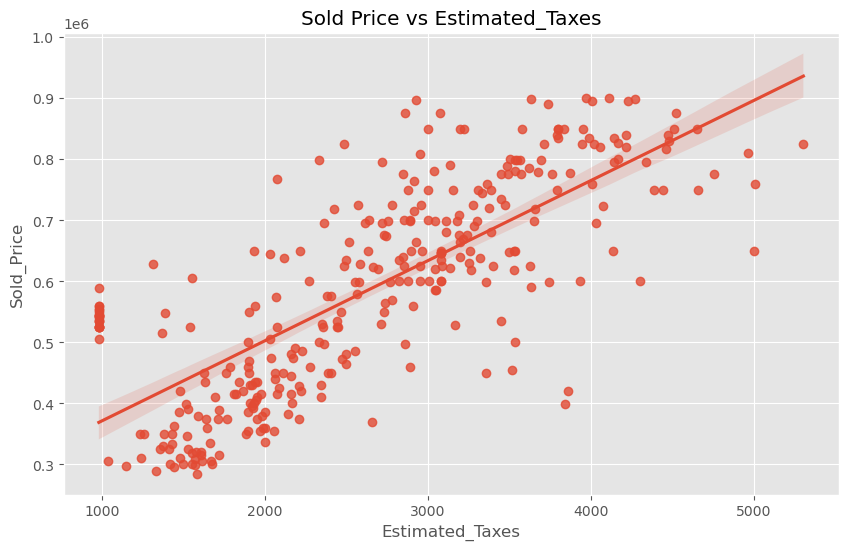

In [125]:
sns.regplot(
    data=cleaned_df,
    x="Estimated_Taxes",
    y="Sold_Price"
)

plt.title("Sold Price vs Estimated_Taxes")
plt.show()

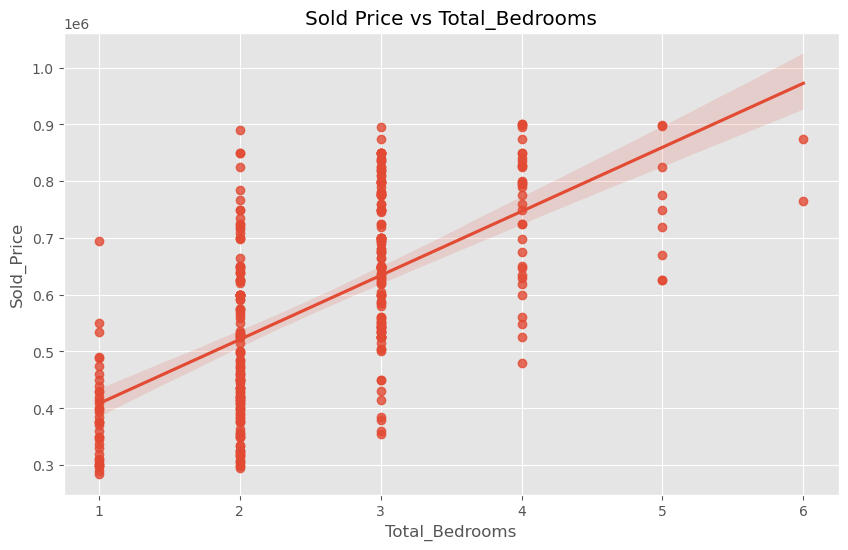

In [126]:
sns.regplot(
    data=cleaned_df,
    x="Total_Bedrooms",
    y="Sold_Price"
)

plt.title("Sold Price vs Total_Bedrooms")
plt.show()

Both plot shows a positive trend between the features and the sold price. In the plot with the estimate tax, we can see the distribution of the data points follow closesly with the regression line. The estimated tax is direcly related to the listing price which could explain why this is a strong predicter for the sold price. The plot for total bedrooms shows a weaker relationship. Bedroom counts are discrete variables so the distribution of the data points are vertical for each count. The variability for the sold price is not really well explained by the number of bedroom where for 2 or 3 bedrooms, the price vaires for a wide range. The number of bedrooms could be associated with total square feet and affect the listing price. This is why the number of bedrooms can partially explain the sold price but not a strong predictor for it.